## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb 

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice. 
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
import seaborn as sn

/home/trevor/anaconda3/envs/textmining/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

In [3]:
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
print(len(train))
train.head(5)

2251


,text,labels
0,WHile we are on the subject of the shuttle sof...,3
1,There is a program called Graphic Workshop you...,1
2,,2
3,My girlfriend is in pain from kidney stones. S...,2
4,I think that's the correct spelling..\n\tI am ...,2


In [4]:
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})
print(len(test))
test.head(5)

1498


,text,labels
0,\nAnd guess who's here in your place.\n\nPleas...,1
1,Does anyone know if any of Currier and Ives et...,1
2,=FLAME ON\n=\n=Reading through the posts about...,2
3,\nBut in this case I said I hoped that BCCI wa...,0
4,\nIn the kind I have made I used a Lite sour c...,2


In [5]:
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

In [6]:
# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)

In [7]:
model = ClassificationModel('roberta', 'roberta-base', num_labels=4, args=model_args, use_cuda=True)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
import torch
torch.cuda.empty_cache()

In [9]:
_, history = model.train_model(train, eval_df=dev)

/home/trevor/anaconda3/envs/textmining/lib/python3.12/site-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(
5it [00:00,  5.59it/s]                       
Epoch:   0%|          | 0/10 [00:00<?, ?it/s]/home/trevor/anaconda3/envs/textmining/lib/python3.12/site-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
Epoch 1 of 10:   0%|          | 0/10 [00:00<?, ?it/s]/home/trevor/anaconda3/envs/textmining/lib/python3.12/site-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


1it [00:00,  

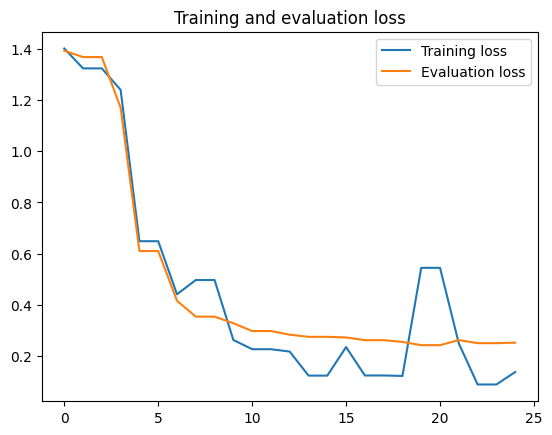

In [10]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [11]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

1it [00:00,  3.31it/s]
Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]/home/trevor/anaconda3/envs/textmining/lib/python3.12/site-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Running Evaluation: 100%|██████████| 3/3 [00:00<00:00,  5.20it/s]


{'mcc': 0.8524830578789689, 'eval_loss': 0.25312189757823944}

In [12]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

3it [00:00,  3.73it/s]                       
Predicting:   0%|          | 0/15 [00:00<?, ?it/s]/home/trevor/anaconda3/envs/textmining/lib/python3.12/site-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Predicting: 100%|██████████| 15/15 [00:03<00:00,  4.35it/s]


In [13]:
test.head(5)

,text,labels,predicted
0,\nAnd guess who's here in your place.\n\nPleas...,1,1
1,Does anyone know if any of Currier and Ives et...,1,1
2,=FLAME ON\n=\n=Reading through the posts about...,2,2
3,\nBut in this case I said I hoped that BCCI wa...,0,0
4,\nIn the kind I have made I used a Lite sour c...,2,2


In [14]:
print(classification_report(test['labels'], test['predicted']))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       319
           1       0.90      0.91      0.91       389
           2       0.91      0.87      0.89       396
           3       0.80      0.85      0.83       394

    accuracy                           0.86      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.86      0.86      0.86      1498

